In [3]:
!pip install openpyxl -qq
!pip install dataretrieval
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dataretrieval import waterdata
import dataretrieval.nwis as nwis
import pandas as pd

In [4]:
filepath1 = './HydroData/2026SoilWetness.csv'
filepath2 = './HydroData/dailydata2026.csv'

In [5]:
soil =  pd.read_csv(filepath1)
weather =  pd.read_csv(filepath2)

In [6]:
new_colnames_sm = {'sm_surface_wetness': 'Soil Moisture Surface Wetness'}

df_sm = soil[['sm_surface_wetness', 'Date']].copy()
df_sm = df_sm.rename(columns=new_colnames_sm)
df_sm['Date'] = pd.to_datetime(df_sm['Date'])
df_sm = df_sm.set_index('Date')

new_colnames_weather = {
    'DATE': 'Date',
    'PRCP': 'Precipitation',
    'SNOW': 'Snow Fall',
    'SNWD': 'Snow Depth'
}

df_weather = weather[['DATE', 'PRCP', 'SNOW', 'SNWD']].copy()
df_weather = df_weather.rename(columns=new_colnames_weather)
df_weather['Date'] = pd.to_datetime(df_weather['Date'])
df_weather = df_weather.set_index('Date')

/tmp/ipykernel_476/1335006345.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sm['Date'] = pd.to_datetime(df_sm['Date'])


In [7]:
site_id = "USGS-04118105"
parameter_code = "00065"

start_date = "2026-01-01"
end_date = "2026-05-01"

df_gauge, metadata = waterdata.get_continuous(
    monitoring_location_id=site_id,
    parameter_code=parameter_code,
    time=f"{start_date}/{end_date}"
)
if not df_gauge.empty:
    df_gauge["time"] = pd.to_datetime(df_gauge["time"])

Retrieving: continuous · 1 page · 11,179 rows
No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


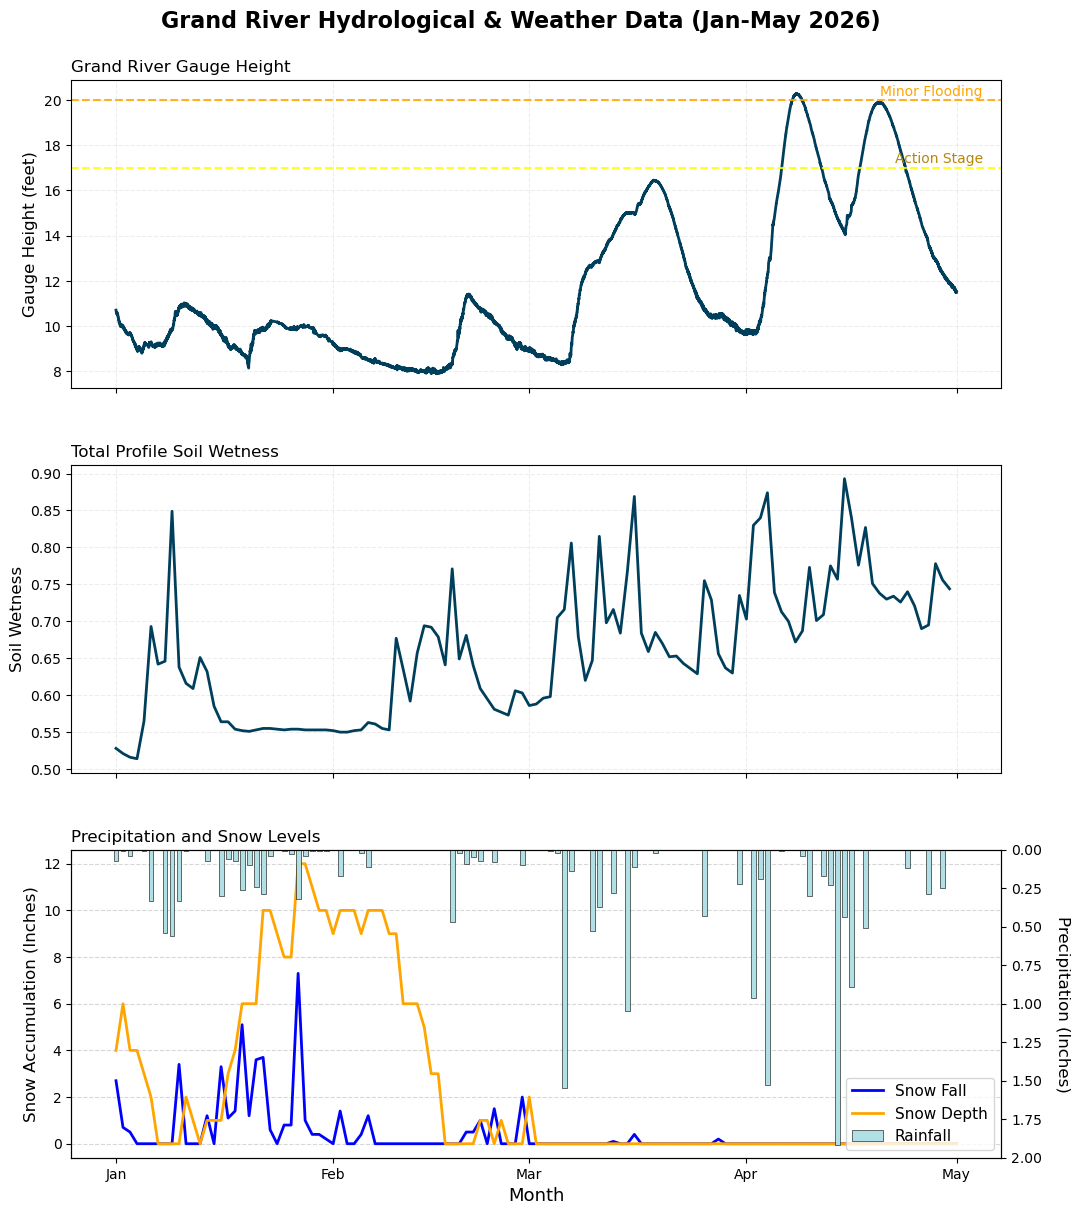

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
fig.suptitle('Grand River Hydrological & Weather Data (Jan-May 2026)', fontsize=16, fontweight='bold', y=0.93)

if not df_gauge.empty:
    axes[0].plot(df_gauge["time"], df_gauge["value"], label="2026", linewidth=2, color="#003f5c")

axes[0].axhline(y=17, color='yellow', linestyle='--', linewidth=1.5, alpha=0.85)
axes[0].axhline(y=20, color='orange', linestyle='--', linewidth=1.5, alpha=0.85)

axes[0].text(0.98, 17.2, "Action Stage", transform=axes[0].get_yaxis_transform(), fontsize=10, ha='right', color='darkgoldenrod')
axes[0].text(0.98, 20.2, "Minor Flooding", transform=axes[0].get_yaxis_transform(), fontsize=10, ha='right', color='orange')

axes[0].set_ylabel("Gauge Height (feet)", fontsize=12)
axes[0].set_title("Grand River Gauge Height", fontsize=12, loc='left')
axes[0].grid(True, linestyle='--', alpha=0.5, color='gainsboro')

axes[1].plot(df_sm.index, df_sm['Soil Moisture Surface Wetness'], label="2026", linewidth=2, color="#003f5c")
axes[1].set_ylabel("Soil Wetness", fontsize=12)
axes[1].set_title("Total Profile Soil Wetness", fontsize=12, loc='left')
axes[1].grid(True, linestyle='--', alpha=0.5, color='gainsboro')

snow_fall = axes[2].plot(df_weather.index, df_weather['Snow Fall'], label='Snow Fall', color='blue', linewidth=2)
snow_depth = axes[2].plot(df_weather.index, df_weather['Snow Depth'], label='Snow Depth', color='orange', linewidth=2)
axes[2].set_ylabel('Snow Accumulation (Inches)', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

ax_twin = axes[2].twinx()
precip = ax_twin.bar(df_weather.index, df_weather['Precipitation'], color='#B0E0E6', edgecolor='black', width=0.7, linewidth=0.40, label='Rainfall')
ax_twin.set_ylabel('Precipitation (Inches)', fontsize=12, rotation=270, labelpad=20)
ax_twin.invert_yaxis()
ax_twin.set_ylim(2.0, 0)

lines = snow_fall + snow_depth + [precip]
labels = ['Snow Fall', 'Snow Depth', 'Rainfall']
axes[2].legend(lines, labels, loc='lower right', fontsize=11, frameon=True)
axes[2].set_title("Precipitation and Snow Levels", fontsize=12, loc='left')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].set_xlabel('Month', fontsize=13)

plt.subplots_adjust(hspace=0.25)


plt.savefig('grand_river_2026_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
